# 06. 유저 활동성 심화 분석

Stickiness (DAU/WAU), 파레토 분석, 활동 강도를 살펴봅니다.

In [1]:
%%time
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from gharchive.transform import optimize_types
from gharchive.stats import (
    daily_active_users, weekly_cohort_retention, user_activity_summary,
)

DATA_DIR = Path("/Users/kakao/bda-2/data/daily_agg")

frames = []
for path in sorted(DATA_DIR.glob("*.parquet")):
    df_part = pd.read_parquet(path)
    df_part["date"] = pd.to_datetime(path.stem, format="%Y%m%d")
    frames.append(df_part)

df = optimize_types(pd.concat(frames, ignore_index=True))
df["week"] = df["date"].dt.to_period("W-SAT").dt.start_time
weeks = sorted(df["week"].unique())

# 05에서 계산된 변수 재생성
retention = weekly_cohort_retention(df)
user_stats = user_activity_summary(df)
dau = daily_active_users(df)

bins = [0, 1, 3, 7, 14, 35]
labels = ["1일", "2~3일", "4~7일", "8~14일", "15~35일"]
user_stats["segment"] = pd.cut(user_stats["active_days"], bins=bins, labels=labels)
segment_counts = user_stats["segment"].value_counts().reindex(labels)

# WAU
first_week = df.groupby("actor_id")["week"].min()
wau_data = []
for w in weeks:
    active = set(df[df["week"] == w]["actor_id"].unique())
    new = set(first_week[first_week == w].index)
    returning = active - new
    wau_data.append({"week": w, "wau": len(active), "new_users": len(new), "returning_users": len(returning)})
wau = pd.DataFrame(wau_data)
wau["new_pct"] = wau["new_users"] / wau["wau"] * 100

print(f"Loaded: {len(df):,} rows, {df["date"].nunique()} days, {df["actor_id"].nunique():,} users")


Loaded: 48,422,013 rows, 35 days, 7,028,338 users
CPU times: user 8min 2s, sys: 20.7 s, total: 8min 23s
Wall time: 8min 54s


## 2. Stickiness (DAU/WAU)

"주간 활성 유저 중 매일 접속하는 비율"을 나타내는 지표입니다.
- 1/7 (14.3%) = 주 1회, 7/7 (100%) = 매일 접속
- 서비스의 습관성/중독성을 측정하는 핵심 지표

<timed exec>:37: UserWarning: Glyph 51452 (\N{HANGUL SYLLABLE JU}) missing from font(s) DejaVu Sans.
<timed exec>:37: UserWarning: Glyph 54924 (\N{HANGUL SYLLABLE HOE}) missing from font(s) DejaVu Sans.
/Users/kakao/bda-2/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51452 (\N{HANGUL SYLLABLE JU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/kakao/bda-2/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 54924 (\N{HANGUL SYLLABLE HOE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


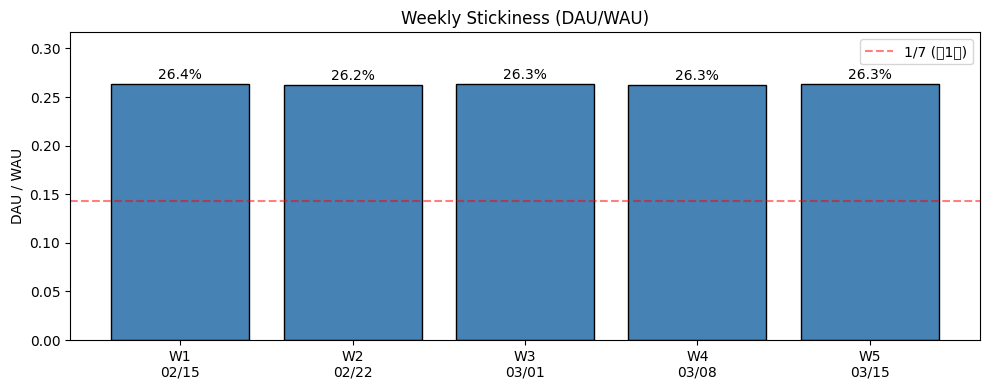

      week       avg_dau     wau  stickiness
2026-02-15 627124.142857 2376903    0.263841
2026-02-22 670182.571429 2554095    0.262395
2026-03-01 688112.428571 2612778    0.263364
2026-03-08 704777.857143 2681235    0.262856
2026-03-15 692137.000000 2626728    0.263498
CPU times: user 8.72 s, sys: 1.15 s, total: 9.86 s
Wall time: 10.4 s


In [2]:
%%time
from gharchive.stats import daily_active_users

dau = daily_active_users(df)
dau["week"] = dau["date"].dt.to_period("W-SAT").dt.start_time

# 주별 평균 DAU / WAU
stickiness_data = []
for w in weeks:
    week_dau = dau[dau["week"] == w]["dau"].mean()
    week_wau = wau[wau["week"] == w]["wau"].values[0]
    stickiness_data.append({
        "week": w,
        "avg_dau": week_dau,
        "wau": week_wau,
        "stickiness": week_dau / week_wau,
    })

stickiness = pd.DataFrame(stickiness_data)

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(
    range(len(stickiness)),
    stickiness["stickiness"],
    color="steelblue",
    edgecolor="black",
)
for i, row in stickiness.iterrows():
    ax.text(i, row["stickiness"] + 0.005, f"{row['stickiness']:.1%}", ha="center", fontsize=10)

ax.set_xticks(range(len(stickiness)))
ax.set_xticklabels([f"W{i+1}\n{w.strftime('%m/%d')}" for i, w in enumerate(stickiness["week"])])
ax.set_ylabel("DAU / WAU")
ax.set_title("Weekly Stickiness (DAU/WAU)")
ax.axhline(y=1/7, color="red", linestyle="--", alpha=0.5, label="1/7 (주1회)")
ax.legend()
ax.set_ylim(0, max(stickiness["stickiness"]) * 1.2)
plt.tight_layout()
plt.show()

print(stickiness[["week", "avg_dau", "wau", "stickiness"]].to_string(index=False))

## 3. 파레토 분석 (이벤트 집중도)

상위 N% 유저가 전체 이벤트의 몇 %를 차지하는지 확인합니다.
- 파레토 법칙(80/20 rule): 상위 20%가 80%를 차지하는가?

=== 파레토 분석 ===
  상위  1% (   70,283명) → 전체 이벤트의 53.0%
  상위  5% (  351,416명) → 전체 이벤트의 69.3%
  상위 10% (  702,833명) → 전체 이벤트의 77.6%
  상위 20% (1,405,667명) → 전체 이벤트의 86.2%
  상위 50% (3,514,169명) → 전체 이벤트의 95.8%


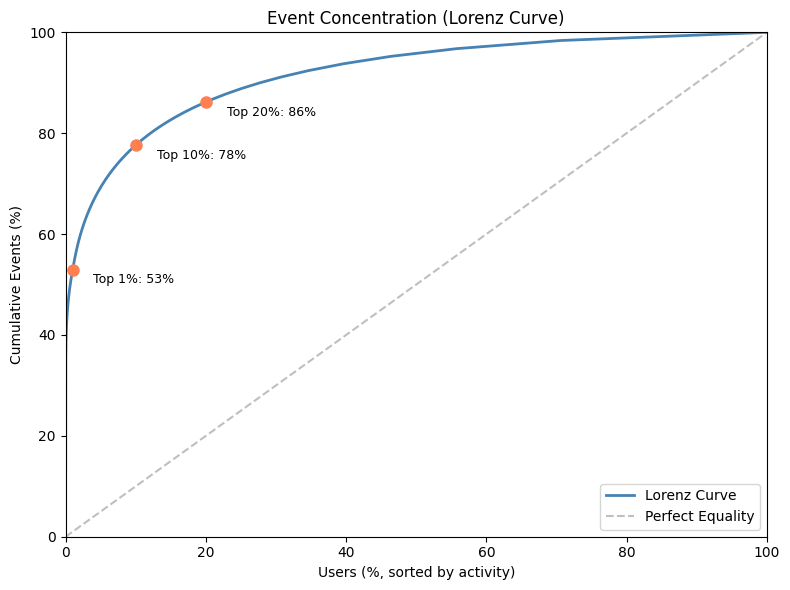

CPU times: user 1.44 s, sys: 191 ms, total: 1.63 s
Wall time: 1.7 s


In [3]:
%%time
# 유저별 총 이벤트 수 (내림차순 정렬)
events_per_user = user_stats["total_events"].sort_values(ascending=False).values
total_events = events_per_user.sum()
n_users = len(events_per_user)

# 누적 비율 계산
cumulative_events = np.cumsum(events_per_user) / total_events * 100
user_pct = np.arange(1, n_users + 1) / n_users * 100

# 주요 포인트 계산
checkpoints = [1, 5, 10, 20, 50]
print("=== 파레토 분석 ===")
for cp in checkpoints:
    idx = int(n_users * cp / 100) - 1
    print(f"  상위 {cp:>2}% ({n_users * cp // 100:>9,}명) → 전체 이벤트의 {cumulative_events[idx]:.1f}%")

# 로렌츠 곡선
fig, ax = plt.subplots(figsize=(8, 6))

ax.plot(user_pct, cumulative_events, color="steelblue", linewidth=2, label="Lorenz Curve")
ax.plot([0, 100], [0, 100], color="gray", linestyle="--", alpha=0.5, label="Perfect Equality")

# 주요 포인트 표시
for cp in [1, 10, 20]:
    idx = int(n_users * cp / 100) - 1
    ax.plot(cp, cumulative_events[idx], "o", color="coral", markersize=8)
    ax.annotate(
        f"Top {cp}%: {cumulative_events[idx]:.0f}%",
        (cp, cumulative_events[idx]),
        textcoords="offset points", xytext=(15, -10), fontsize=9,
    )

ax.set_xlabel("Users (%, sorted by activity)")
ax.set_ylabel("Cumulative Events (%)")
ax.set_title("Event Concentration (Lorenz Curve)")
ax.legend(loc="lower right")
ax.set_xlim(0, 100)
ax.set_ylim(0, 100)
plt.tight_layout()
plt.show()

## 4. 활동 강도 (Events per Active Day)

활동일당 평균 이벤트 수 — "활동할 때 얼마나 열심히 하는가"를 측정합니다.
활동 일수가 많아도 하루에 1~2개만 하는 유저 vs 하루에 수백 개씩 하는 유저를 구분할 수 있습니다.

활동 강도 (events/active day) 분포:


count        7028338.0
mean          2.750732
std         189.481443
min                1.0
25%                1.0
50%                1.5
75%           2.714286
max      482425.485714

중앙값: 1.5


p90:    4.6
p99:    14.3


<timed exec>:32: UserWarning: Glyph 51068 (\N{HANGUL SYLLABLE IL}) missing from font(s) DejaVu Sans.


/Users/kakao/bda-2/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51068 (\N{HANGUL SYLLABLE IL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


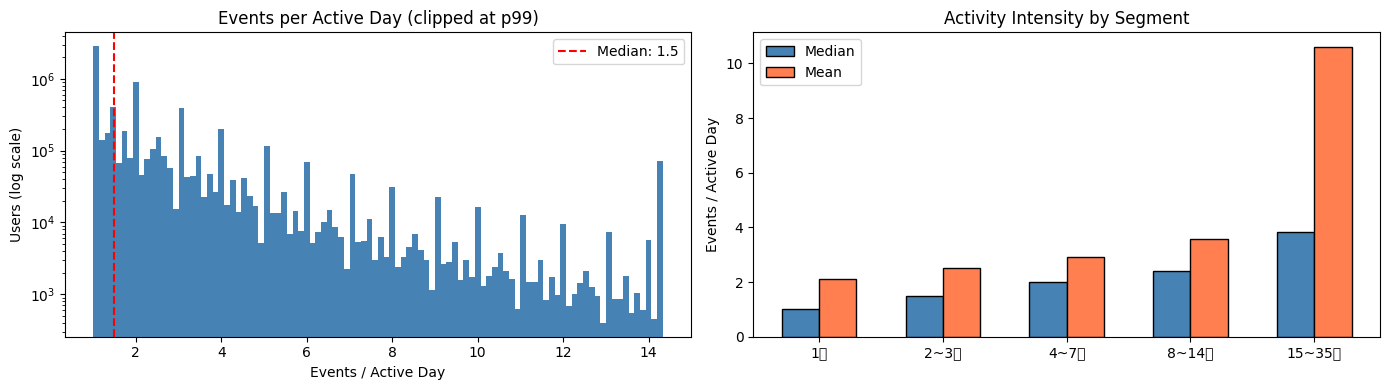

CPU times: user 1.96 s, sys: 161 ms, total: 2.12 s
Wall time: 2.22 s


In [4]:
%%time
user_stats["events_per_day"] = user_stats["total_events"] / user_stats["active_days"]

print("활동 강도 (events/active day) 분포:")
print(user_stats["events_per_day"].describe().to_string())
print(f"\n중앙값: {user_stats['events_per_day'].median():.1f}")
print(f"p90:    {user_stats['events_per_day'].quantile(0.9):.1f}")
print(f"p99:    {user_stats['events_per_day'].quantile(0.99):.1f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# 전체 분포 (log scale, 상위 극단값 클리핑)
clipped = user_stats["events_per_day"].clip(upper=user_stats["events_per_day"].quantile(0.99))
axes[0].hist(clipped, bins=100, color="steelblue", edgecolor="none", log=True)
axes[0].set_title("Events per Active Day (clipped at p99)")
axes[0].set_xlabel("Events / Active Day")
axes[0].set_ylabel("Users (log scale)")
axes[0].axvline(user_stats["events_per_day"].median(), color="red", linestyle="--", label=f"Median: {user_stats['events_per_day'].median():.1f}")
axes[0].legend()

# 세그먼트별 활동 강도 비교
seg_intensity = user_stats.groupby("segment")["events_per_day"].agg(["median", "mean"]).reindex(labels)

x = range(len(labels))
axes[1].bar([i - 0.15 for i in x], seg_intensity["median"], width=0.3, label="Median", color="steelblue", edgecolor="black")
axes[1].bar([i + 0.15 for i in x], seg_intensity["mean"], width=0.3, label="Mean", color="coral", edgecolor="black")
axes[1].set_xticks(x)
axes[1].set_xticklabels(labels)
axes[1].set_title("Activity Intensity by Segment")
axes[1].set_ylabel("Events / Active Day")
axes[1].legend()

plt.tight_layout()
plt.show()

## 5. 정리

In [5]:
%%time
# 주요 수치 정리
print("=== Weekly Retention ===")
print(f"W1→W2 retention: {retention.iloc[0, 1]*100:.1f}%")
if retention.shape[1] > 2:
    print(f"W1→W3 retention: {retention.iloc[0, 2]*100:.1f}%")

print(f"\n=== User Segments ===")
for label in labels:
    cnt = segment_counts[label]
    pct = cnt / len(user_stats) * 100
    print(f"  {label:>8}: {cnt:>10,} ({pct:.1f}%)")

print(f"\n=== Stickiness (DAU/WAU) ===")
print(f"평균: {stickiness['stickiness'].mean():.1%}")

print(f"\n=== 파레토 ===")
for cp in [1, 10, 20]:
    idx = int(n_users * cp / 100) - 1
    print(f"  상위 {cp:>2}% → 전체 이벤트의 {cumulative_events[idx]:.1f}%")

print(f"\n=== 활동 강도 ===")
print(f"전체 중앙값: {user_stats['events_per_day'].median():.1f} events/day")
print(f"파워유저(15일+) 중앙값: {user_stats[user_stats['segment'] == '15~35일']['events_per_day'].median():.1f} events/day")

print(f"\n=== WAU ===")
print(f"평균 WAU: {wau['wau'].mean():,.0f}")
print(f"평균 신규 비율: {wau['new_pct'].mean():.1f}%")

=== Weekly Retention ===
W1→W2 retention: 46.2%
W1→W3 retention: 39.7%

=== User Segments ===
        1일:  3,276,432 (46.6%)
      2~3일:  1,945,546 (27.7%)
      4~7일:  1,080,540 (15.4%)
     8~14일:    477,145 (6.8%)
    15~35일:    248,675 (3.5%)

=== Stickiness (DAU/WAU) ===
평균: 26.3%

=== 파레토 ===
  상위  1% → 전체 이벤트의 53.0%
  상위 10% → 전체 이벤트의 77.6%
  상위 20% → 전체 이벤트의 86.2%

=== 활동 강도 ===
전체 중앙값: 1.5 events/day


파워유저(15일+) 중앙값: 3.8 events/day

=== WAU ===
평균 WAU: 2,570,348
평균 신규 비율: 55.6%
CPU times: user 192 ms, sys: 365 ms, total: 557 ms
Wall time: 631 ms
